I acknowledge the use of Copilot in the completion of this assignment. The Copilot was used in the following ways in this assignment: merging the datasets.

Regression Results (R2 Score):
Linear Regression: 0.3014
Random Forest:     0.5214
kNN Regressor:     0.1524

Classification Results (Accuracy):
Logistic Regression: 0.7200
Random Forest:       0.7861
kNN Classifier:      0.6817


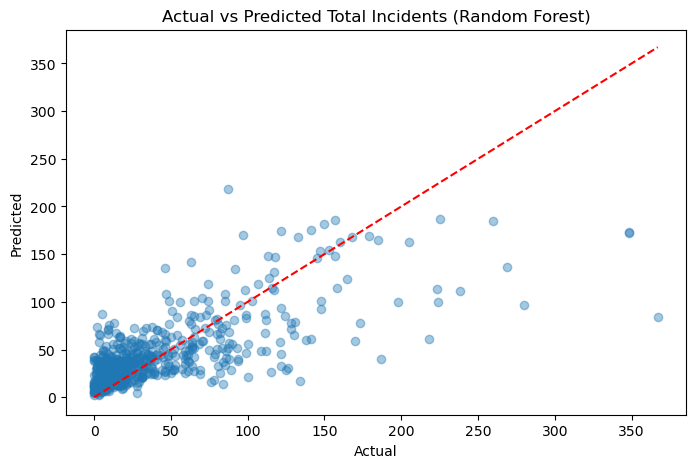

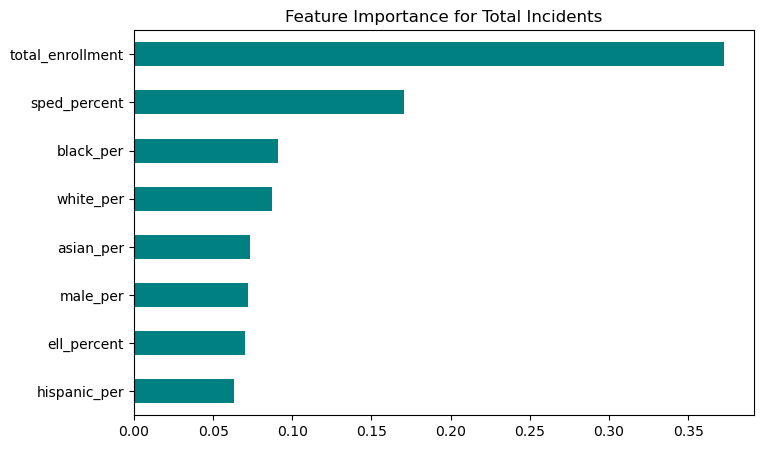

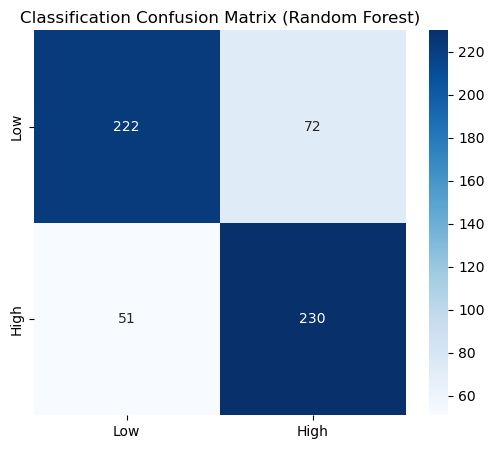

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix

demographics_df = pd.read_csv('https://docs.google.com/spreadsheets/d/e/2PACX-1vRSnla2AtvwQL1VIdBMtScWgb7HOfT3PfNTSKEbyYbweLV6oI9tSlLgMlWw37x31WBxGQePIiF_d5yi/pub?output=csv')
incidents_df = pd.read_csv('https://docs.google.com/spreadsheets/d/e/2PACX-1vSPeJtPExJ-z5UdNprXAJrFG9PIRkltJGDzuDC2cQ9nOIUD73pp5MZjgWDvT5MPq8RcZMTTrRtLeFin/pub?output=csv')

demographics_df['Name_clean'] = demographics_df['Name'].str.upper().str.strip()
incidents_df['School Name_clean'] = incidents_df['School Name'].str.upper().str.strip()

def format_year(y):
    y_str = str(y)
    if len(y_str) == 8:
        return f"{y_str[:4]}-{y_str[4:]}"
    return y_str

demographics_df['School Year_clean'] = demographics_df['schoolyear'].apply(format_year)
incidents_df['School Year_clean'] = incidents_df['School Year'].str.strip()

incident_cols = [
    'Homicide With Weapon(s)', 'Homicide Without Weapon(s)',
    'Forcible Sex Offenses With Weapon(s)', 'Forcible Sex Offenses Without Weapon(s)',
    'Other Sex Offenses With Weapon(s)', 'Other Sex Offenses Without Weapon(s)',
    'Robbery With Weapon(s)', 'Robbery Without Weapon(s)',
    'Assault With Serious Physical Injury With Weapon(s)',
    'Assault With Serious Physical Injury Without Weapon(s)',
    'Arson With Weapon(s)', 'Kidnapping With Weapon(s)',
    'Kidnapping Without Weapon(s)', 'Assault with Physical Injury With Weapon(s)',
    'Assault with Physical Injury Without Weapon(s)',
    'Reckless Endangerment With Weapon(s)', 'Reckless Endangerment Without Weapon(s)',
    'Minor Altercations With Weapon(s)', 'Minor Altercations Without Weapon(s)',
    'Intimidation, Harassment, Menacing, or Bullying With Weapon(s)',
    'Intimidation, Harassment, Menacing, or Bullying Without Weapon(s)',
    'Burglary With Weapon(s)', 'Burglary Without Weapon(s)',
    'Criminal Mischief With Weapon(s)', 'Criminal Mischief Without Weapon(s)',
    'Larceny, or Other Theft With Weapon(s)', 'Larceny, or Other Theft Without Weapon(s)',
    'Bomb Threat', 'False Alarm', 'Riot With Weapon(s)', 'Riot Without Weapon(s)',
    'Weapon PossessionThrough Screening', 'Weapon Possession Under Other Circumstances',
    'Drug Possession', 'Alcohol Possession', 'Other Disruptive'
]

for col in incident_cols:
    incidents_df[col] = pd.to_numeric(incidents_df[col], errors='coerce').fillna(0)

incidents_df['Total_Incidents'] = incidents_df[incident_cols].sum(axis=1)

merged_df = pd.merge(
    demographics_df, 
    incidents_df, 
    left_on=['Name_clean', 'School Year_clean'], 
    right_on=['School Name_clean', 'School Year_clean'],
    how='inner'
)

features = [
    'total_enrollment', 'ell_percent', 'sped_percent', 
    'asian_per', 'black_per', 'hispanic_per', 'white_per', 'male_per'
]

for feat in features:
    merged_df[feat] = pd.to_numeric(merged_df[feat], errors='coerce')

model_data = merged_df[features + ['Total_Incidents']].dropna()

X = model_data[features]
y_reg = model_data['Total_Incidents']
X_train, X_test, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size=0.2, random_state=42)

# Method 1: Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train_reg)
y_pred_lr = lr.predict(X_test)

# Method 2: Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train, y_train_reg)
y_pred_rf_reg = rf_reg.predict(X_test)

# Method 3: k-Nearest Neighbors Regressor
knn_reg = KNeighborsRegressor(n_neighbors=5)
knn_reg.fit(X_train, y_train_reg)
y_pred_knn_reg = knn_reg.predict(X_test)

# Evaluate Regression
print("Regression Results (R2 Score):")
print(f"Linear Regression: {r2_score(y_test_reg, y_pred_lr):.4f}")
print(f"Random Forest:     {r2_score(y_test_reg, y_pred_rf_reg):.4f}")
print(f"kNN Regressor:     {r2_score(y_test_reg, y_pred_knn_reg):.4f}")

median_inc = model_data['Total_Incidents'].median()
model_data['High_Incidents'] = (model_data['Total_Incidents'] > median_inc).astype(int)
y_clf = model_data['High_Incidents']

X_train_c, X_test_c, y_train_clf, y_test_clf = train_test_split(X, y_clf, test_size=0.2, random_state=42)

# Method 1: Logistic Regression
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_c, y_train_clf)
y_pred_log = log_reg.predict(X_test_c)

# Method 2: Random Forest Classifier
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train_c, y_train_clf)
y_pred_rf_clf = rf_clf.predict(X_test_c)

# Method 3: k-Nearest Neighbors Classifier
knn_clf = KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(X_train_c, y_train_clf)
y_pred_knn_clf = knn_clf.predict(X_test_c)

# Evaluate Classification
print("\nClassification Results (Accuracy):")
print(f"Logistic Regression: {accuracy_score(y_test_clf, y_pred_log):.4f}")
print(f"Random Forest:       {accuracy_score(y_test_clf, y_pred_rf_clf):.4f}")
print(f"kNN Classifier:      {accuracy_score(y_test_clf, y_pred_knn_clf):.4f}")

# Actual vs Predicted Plot
plt.figure(figsize=(8, 5))
plt.scatter(y_test_reg, y_pred_rf_reg, alpha=0.4)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--')
plt.title('Actual vs Predicted Total Incidents (Random Forest)')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.savefig('regression_performance.png')

# Feature Importance
importances = pd.Series(rf_reg.feature_importances_, index=features).sort_values()
plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='teal')
plt.title('Feature Importance for Total Incidents')
plt.savefig('feature_importance.png')

# Confusion Matrix
cm = confusion_matrix(y_test_clf, y_pred_rf_clf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Low', 'High'], yticklabels=['Low', 'High'])
plt.title('Classification Confusion Matrix (Random Forest)')
plt.savefig('classification_cm.png')